In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv(r"C:\Users\Dell\Desktop\final year project\Dataset\phishing.csv")

data.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [20]:
print(data.shape)
print(data.columns)
data.head()
data['class'].value_counts()
data['class'] = data['class'].replace(-1, 0)
X = data.drop('class', axis=1)
y = data['class']


(11054, 32)
Index(['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//',
       'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon',
       'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL',
       'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL',
       'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
       'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
       'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage',
       'StatsReport', 'class'],
      dtype='object')


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='l2', max_iter=2000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

Accuracy: 0.9335142469470827
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       976
           1       0.93      0.95      0.94      1235

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9678878335594754


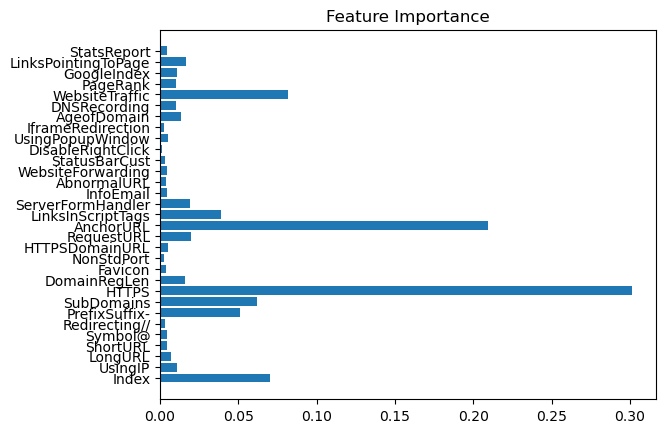

In [23]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1:", f1_score(y_test, predictions))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall:", recall_score(y_test, rf_predictions))
print("F1:", f1_score(y_test, rf_predictions))

Logistic Regression
Accuracy: 0.9335142469470827
Precision: 0.9283464566929134
Recall: 0.9546558704453442
F1: 0.9413173652694611

Random Forest
Accuracy: 0.9678878335594754
Precision: 0.9693548387096774
Recall: 0.9732793522267207
F1: 0.9713131313131312


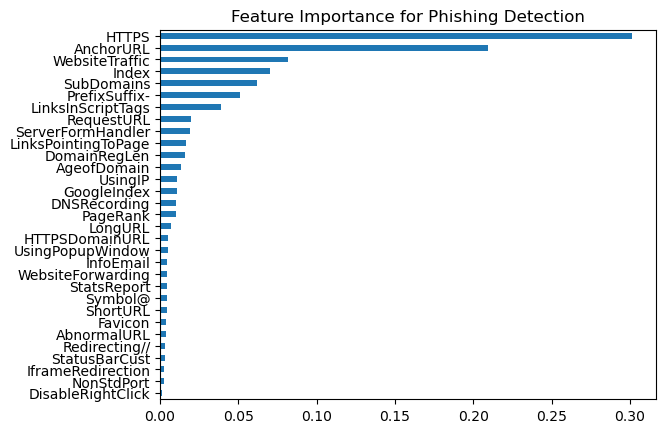

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

importance = rf.feature_importances_
features = X.columns

feature_importance = pd.Series(importance, index=features)

feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance for Phishing Detection")
plt.show()

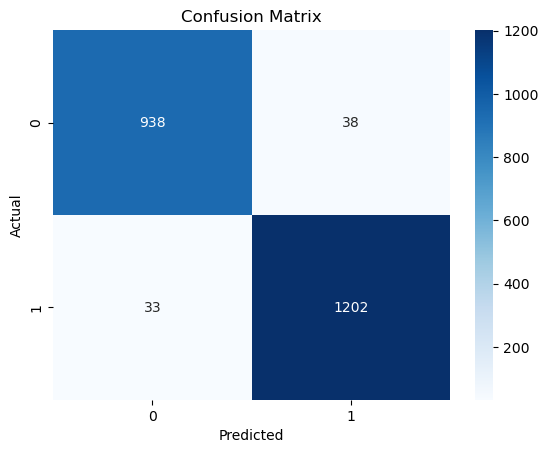

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
import joblib
import json

# Save the model
joblib.dump(rf, 'phishing_model.pkl')  # saving Random Forest (better accuracy)

# Save feature names so app.py knows what to expect
feature_names = X.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Model saved!")
print("Features:", feature_names)
print("Number of features:", len(feature_names))

Model saved!
Features: ['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport']
Number of features: 31


In [29]:
import joblib
joblib.dump(rf, 'phishing_model.pkl')  # save Random Forest

['phishing_model.pkl']

In [30]:
import pandas as pd
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False).head(15))

HTTPS                  0.301544
AnchorURL              0.209454
WebsiteTraffic         0.081823
Index                  0.070132
SubDomains             0.061913
PrefixSuffix-          0.051066
LinksInScriptTags      0.038632
RequestURL             0.019943
ServerFormHandler      0.019366
LinksPointingToPage    0.016620
DomainRegLen           0.015782
AgeofDomain            0.013138
UsingIP                0.010996
GoogleIndex            0.010874
DNSRecording           0.010183
dtype: float64


In [34]:
# Re-read the original dataset fresh
data2 = pd.read_csv(r"C:\Users\Dell\Desktop\final year project\Dataset\phishing.csv")

print("Original classes:", data2['class'].unique())
print(data2['class'].value_counts())

# Correct mapping from scratch
# In original: 1 = legitimate, -1 = phishing
data2['class'] = data2['class'].map({1: 0, -1: 1})
# Now: 0 = legitimate, 1 = phishing

print("\nAfter fix:")
print(data2['class'].value_counts())

X2 = data2.drop('class', axis=1)
y2 = data2['class']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf2 = RandomForestClassifier(n_estimators=100)
rf2.fit(X_train2, y_train2)

print("Accuracy:", accuracy_score(y_test2, rf2.predict(X_test2)))

import joblib
joblib.dump(rf2, r'C:\Users\Dell\Desktop\final year project\phishing_app\phishing_app\phishing_model.pkl')
print("✅ Model saved correctly!")

Original classes: [-1  1]
 1    6157
-1    4897
Name: class, dtype: int64

After fix:
0    6157
1    4897
Name: class, dtype: int64
Accuracy: 0.9687924016282226
✅ Model saved correctly!


In [35]:
import sklearn
print(sklearn.__version__)  # note this version

1.2.1
